# UTS Eksplorasi dan Visualisasi Data
## California Housing Dataset Analysis
**Program Studi:** Statistika | **Kelas:** A1
**Mata Kuliah:** Eksplorasi dan Visualisasi Data
**Dosen:** Amanatullah Pandu Zenklinov, M.Stat.
**Tahun Akademik:** 2025/2026

---
> *Analisis ini dilakukan dalam konteks rekrutmen Data Scientist oleh Trevor, pemilik Perusahaan Pemetaan Perumahan di California, US.*

## Setup & Load Data

In [ ]:
!pip install pandas scikit-learn matplotlib seaborn statsmodels -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# Load dataset
housing_data = fetch_california_housing(as_frame=True)
df = housing_data.frame

print('Shape dataset:', df.shape)
print('\nPreview data:')
df.head()

Shape dataset: (20640, 9)

Preview data:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
# Statistik Deskriptif
print('=== Statistik Deskriptif ===')
df.describe().round(3)

=== Statistik Deskriptif ===


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,3.871,28.639,5.429,1.097,1425.477,3.071,35.632,-119.570,2.069
std,1.900,12.586,2.474,0.474,1132.462,10.386,2.136,2.004,1.154
min,0.500,1.000,0.846,0.333,3.000,0.692,32.540,-124.350,0.150
25%,2.563,18.000,4.441,1.006,787.000,2.430,33.930,-121.800,1.196
50%,3.535,29.000,5.229,1.049,1166.000,2.818,34.260,-118.490,1.797
75%,4.743,37.000,6.052,1.100,1725.000,3.282,37.710,-118.010,2.647
max,15.000,52.000,141.909,34.067,35682.000,1243.333,41.950,-114.310,5.000


---
## SOAL 1: Exploratory Data Analysis (EDA)

### 1a. Pengertian EDA

EDA adalah proses menginterpretasikan data secara awal menggunakan pendekatan visual seperti histogram dan heatmap, serta pendekatan statistik seperti analisis deskriptif dengan tujuan memahami karakteristik data dan menjadikannya sebagai fondasi yang kuat untuk analisis lebih lanjut. Berbeda dengan analisis data teknikal, EDA berfokus pada interpretasi kontekstual tidak hanya mendeskripsikan data tetapi memaknainya dalam konteks yang relevan.

### 1b. Mengapa EDA Penting

EDA penting dilakukan sebelum analisis lanjutan karena beberapa alasan. Pertama, untuk mengidentifikasi outlier apabila terdapat nilai ekstrem yang tidak terdeteksi, visualisasi dan model yang dihasilkan akan timpang sehingga blok-blok lain kehilangan representasinya. Kedua, untuk memahami hierarki data dari nilai tertinggi hingga terendah, sehingga interpretasi ke depan memiliki dasar yang kuat. Ketiga, untuk mengevaluasi keunggulan dan kelemahan dataset termasuk kelengkapan data dan potensi bias yang dapat mempengaruhi analisis selanjutnya.

### 1c. Variabel yang Cocok untuk Setiap Analisis

"Ketujuh variabel numerik yaitu MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, dan MedHouseVal dapat digunakan untuk ketiga jenis analisis. Untuk analisis distribusi dan korelasi, ketujuh variabel tersebut dianalisis secara keseluruhan karena masing-masing memiliki makna numerik yang dapat diukur dan dibandingkan. Untuk analisis regresi, MedHouseVal (Nilai/Harga Rumah Median) ditempatkan sebagai variabel dependen (target) karena tujuan utama dari studi kasus Trevor adalah mengestimasi harga properti di suatu wilayah. Sementara itu, variabel lainnya seperti MedInc (Pendapatan Median), HouseAge, AveRooms, AveBedrms, Population, dan AveOccup berperan sebagai variabel independen (prediktor), mengingat faktor-faktor lingkungan dan daya beli masyarakatlah yang menentukan tinggi rendahnya harga sebuah rumah."

### 1d. Mengapa Latitude & Longitude Dikecualikan

Variabel Latitude dan Longitude tidak diikutsertakan karena keduanya bersifat koordinat geografis secara pragmatis tidak memiliki makna statistik yang fungsional. Angka yang lebih besar pada kedua variabel ini tidak merepresentasikan kondisi yang lebih baik atau buruk, melainkan hanya menunjukkan posisi lokasi suatu blok. Keduanya lebih tepat dianalisis menggunakan pendekatan geospasial seperti peta persebaran, bukan analisis statistik konvensional.

---
## SOAL 2: Visualisasi Distribusi (Histogram)

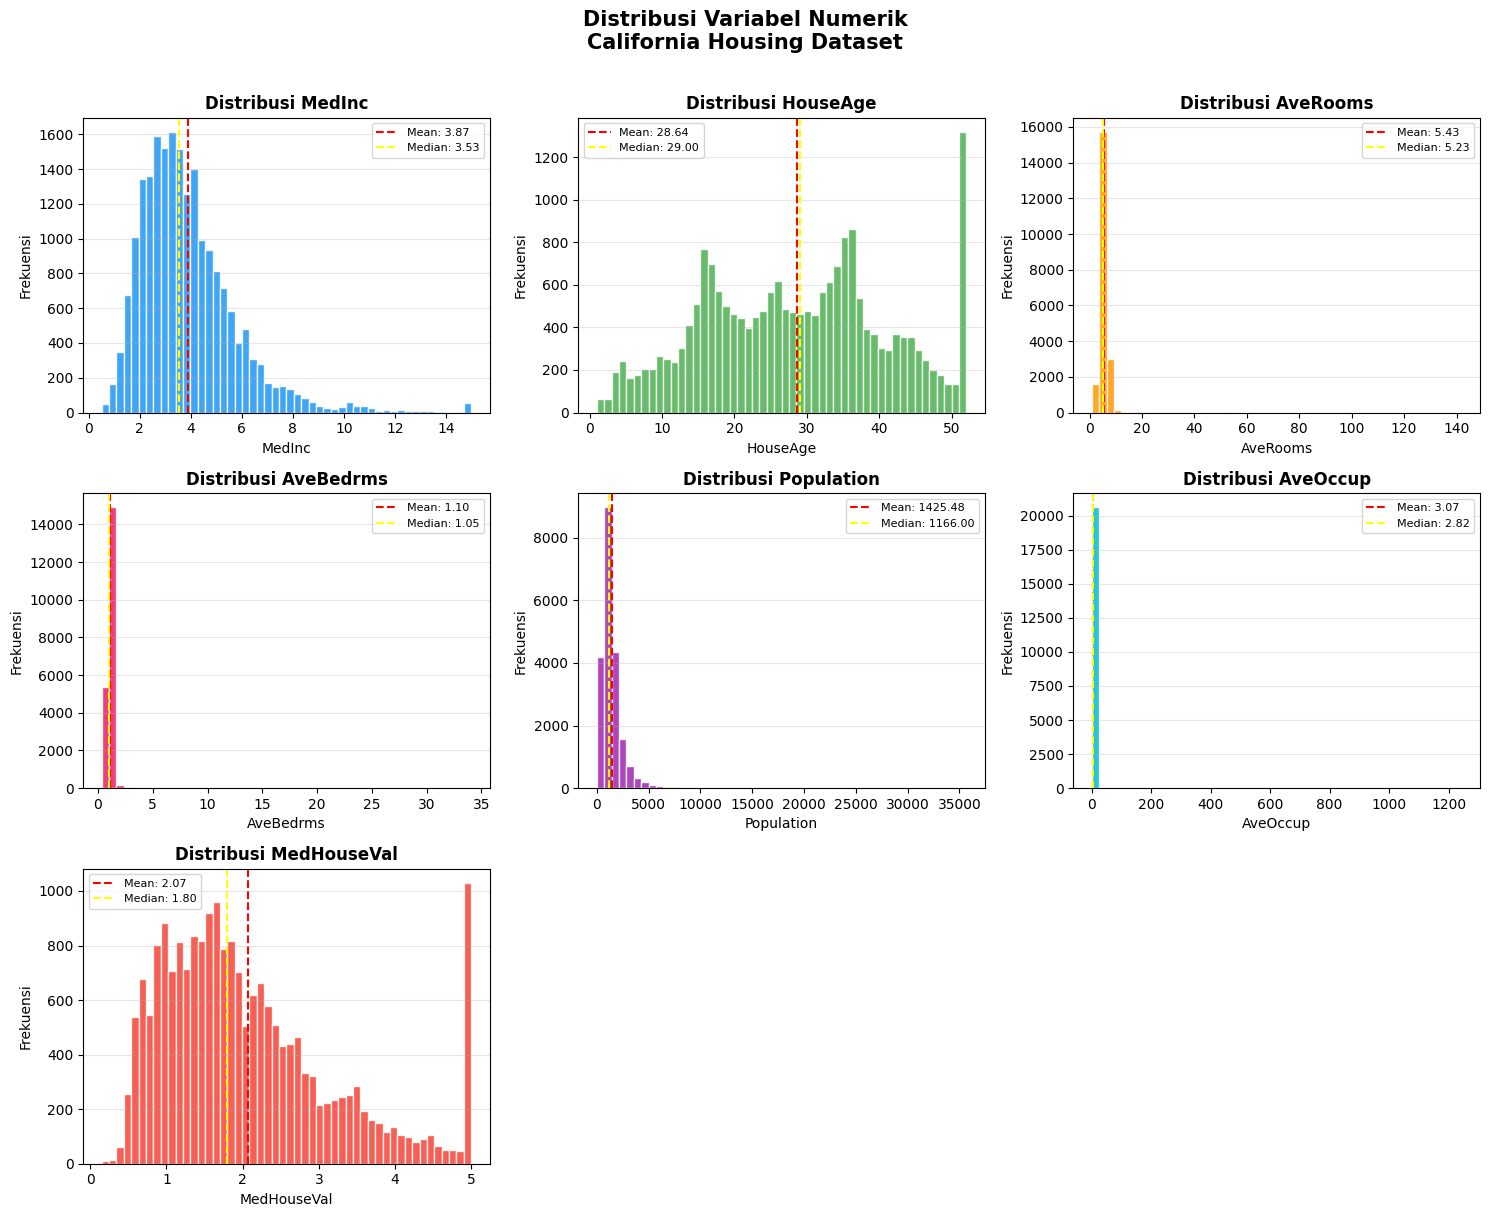

Histogram berhasil ditampilkan.


In [ ]:
cols = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'MedHouseVal']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#00BCD4', '#F44336']

for i, col in enumerate(cols):
    axes[i].hist(df[col], bins=50, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribusi {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Frekuensi', fontsize=10)
    axes[i].axvline(df[col].mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.2f}')
    axes[i].axvline(df[col].median(), color='yellow', linestyle='--', linewidth=1.5, label=f'Median: {df[col].median():.2f}')
    axes[i].legend(fontsize=8)
    axes[i].grid(axis='y', alpha=0.3)

for j in range(len(cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Variabel Numerik\nCalifornia Housing Dataset', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('soal2_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Histogram berhasil ditampilkan.')

### Interpretasi Histogram

**MedInc (Pendapatan Median) :**
Distribusi MedInc bersifat right-skewed dengan mayoritas nilai terkonsentrasi di rentang 2–5 (×$10.000), menunjukkan dominasi kelas menengah ke bawah. Terdapat outlier pada nilai ekstrem yang apabila tidak diidentifikasi sejak awal akan membuat visualisasi tampak timpang dan blok lain kehilangan representasinya. Bagi Trevor, segmen menengah ini merepresentasikan target pasar yang paling jelas.

**Population (Jumlah Penduduk) :**
Distribusi Population bersifat right-skewed dengan mayoritas blok berpopulasi kecil hingga menengah. Blok-blok urban dengan populasi ekstrem jumlahnya sedikit namun berpotensi mendistorsi analisis apabila tidak diidentifikasi sejak awal.

**MedHouseVal (Nilai Median Rumah) :**
Distribusi MedHouseVal bersifat right-skewed dengan mayoritas harga rumah berada di segmen menengah ke bawah. Blok dengan harga ekstrem jumlahnya minoritas namun cukup signifikan sebagai outlier yang perlu diwaspadai.

**HouseAge (Usia Rumah) :**
Distribusi HouseAge didominasi rumah berusia tua, mencerminkan bahwa kota-kota besar California sudah lama berkembang dan memiliki lebih banyak blok dibanding kota suburban yang baru.

**AveRooms & AveBedrms :**
Keduanya berdistribusi right-skewed dengan mayoritas di rentang standar. Kedua variabel ini berkorelasi erat rumah dengan ruangan banyak cenderung memiliki kamar tidur lebih banyak, karena keduanya berada dalam satu konteks yang sama.

**AveOccup (Rata-rata Penghuni) :**
Mayoritas blok memiliki rata-rata 2–4 penghuni per rumah. Terdapat outlier ekstrem yang perlu diwaspadai karena kepadatan penghuni yang sangat tinggi dapat membuat hasil analisis menjadi timpang.

---
## SOAL 3: Analisis Korelasi

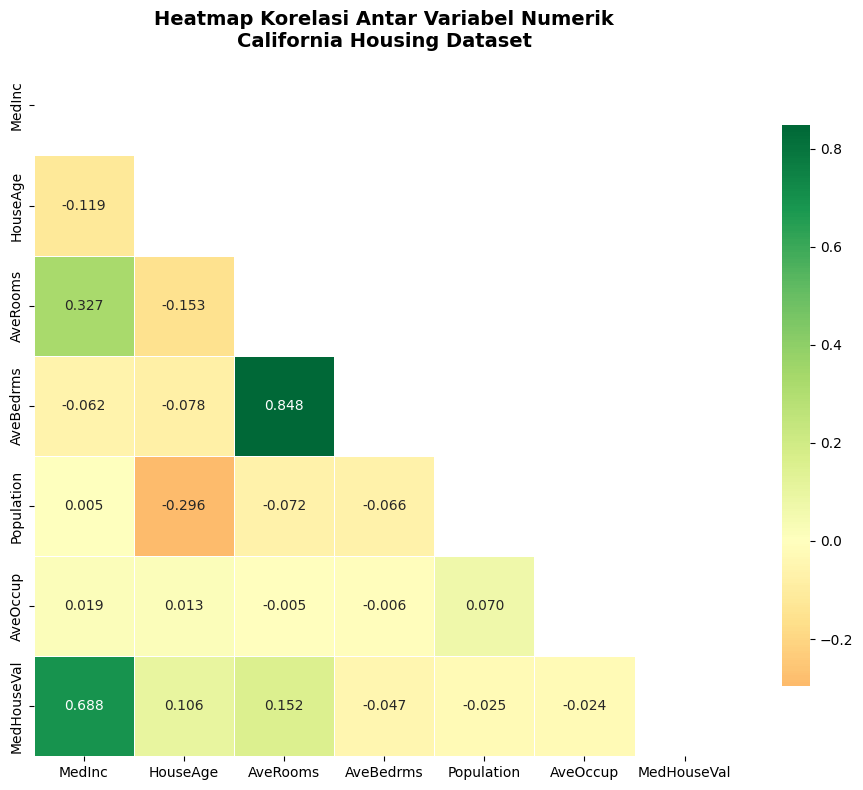

=== Korelasi dengan MedHouseVal ===
MedHouseVal    1.000
MedInc         0.688
AveRooms       0.152
HouseAge       0.106
AveOccup      -0.024
Population    -0.025
AveBedrms     -0.047
Name: MedHouseVal, dtype: float64

✅ Korelasi TERTINGGI: ('AveBedrms', 'AveRooms') = 0.848
❌ Korelasi TERENDAH : ('Population', 'HouseAge') = -0.296

=== Semua Pasangan Korelasi ===
Population   HouseAge     -0.296
AveRooms     HouseAge     -0.153
HouseAge     MedInc       -0.119
AveBedrms    HouseAge     -0.078
Population   AveRooms     -0.072
             AveBedrms    -0.066
AveBedrms    MedInc       -0.062
MedHouseVal  AveBedrms    -0.047
             Population   -0.025
             AveOccup     -0.024
AveOccup     AveBedrms    -0.006
             AveRooms     -0.005
Population   MedInc        0.005
AveOccup     HouseAge      0.013
             MedInc        0.019
             Population    0.070
MedHouseVal  HouseAge      0.106
             AveRooms      0.152
AveRooms     MedInc        0.327
MedHouse

In [ ]:
corr_matrix = df[cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.3f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8},
            mask=mask,
            annot_kws={'size': 10})

plt.title('Heatmap Korelasi Antar Variabel Numerik\nCalifornia Housing Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('soal3_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

# Ambil pasangan unik (segitiga atas saja)
corr_upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
corr_pairs = corr_upper.unstack().dropna().sort_values()

print('=== Korelasi dengan MedHouseVal ===')
print(corr_matrix['MedHouseVal'].sort_values(ascending=False).round(3))
print(f'\n✅ Korelasi TERTINGGI: {corr_pairs.idxmax()} = {corr_pairs.max():.3f}')
print(f'❌ Korelasi TERENDAH : {corr_pairs.idxmin()} = {corr_pairs.min():.3f}')
print('\n=== Semua Pasangan Korelasi ===')
print(corr_pairs.round(3))

### Interpretasi Korelasi

**Korelasi Tertinggi : MedInc ↔ MedHouseVal**
Korelasi tertinggi terjadi antara MedInc dan MedHouseVal, yang mencerminkan konsep eksklusivitas dan daya beli. Harga rumah yang tinggi mengindikasikan bahwa penghuninya memiliki kemampuan ekonomi yang tinggi karena tanpa pendapatan tinggi, mereka tidak mungkin mampu membeli properti bernilai tinggi tersebut.

**Korelasi Terendah : HouseAge ↔ MedInc**
Korelasi terendah terjadi antara HouseAge dan MedInc karena tidak ada pola yang konsisten. Rumah baru mengindikasikan daerah berkembang dengan pendapatan naik, namun rumah tua di daerah premium juga mencerminkan pendapatan tinggi. Kedua kondisi ini saling cancel out sehingga korelasinya sangat lemah.

**Korelasi Surprising : Population ↔ MedHouseVal**
Secara teoritis, populasi tinggi seharusnya mendorong harga rumah naik semakin banyak penduduk, produktivitas stabil, perputaran ekonomi domestik lancar, dan peluang memperluas demand lebih terbuka. Namun data menunjukkan korelasi yang lemah karena populasi tinggi di California terbagi menjadi dua karakter berlawanan: blok urban produktif dan blok overcrowded dengan daya beli rendah. Keduanya saling cancel out mengindikasikan migrasi yang tidak selalu didorong oleh pertumbuhan ekonomi.

**Korelasi Negatif : AveOccup ↔ MedHouseVal**
AveOccup dan Population meskipun terlihat sebagai sebab-akibat, keduanya mengukur hal yang berbeda Population mengukur keramaian blok, sedangkan AveOccup mengukur kepadatan per rumah. Kepadatan penghuni per rumah yang tinggi justru menjadi indikator ketidakmampuan ekonomi. Namun hubungan ini bersifat kondisional pada blok dengan MedInc tinggi, kepadatan tidak selalu berkonotasi negatif karena ditopang oleh daya beli yang kuat.

**Insight :**
Populasi tinggi saja tidak cukup menjadi indikator nilai properti. Diperlukan kombinasi Population dan MedInc secara bersamaan untuk mengidentifikasi daerah yang benar-benar potensial bukan sekadar ramai, tetapi produktif.

---
## SOAL 4: Analisis Regresi Berganda

In [ ]:
X_cols = ['HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'MedHouseVal']
y_col  = 'MedInc'

X = df[X_cols]
y = df[y_col]

X_sm = sm.add_constant(X)
model = sm.OLS(y, X_sm).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 MedInc   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     9505.
Date:                Sun, 05 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:38:32   Log-Likelihood:                -28853.
No. Observations:               20640   AIC:                         5.772e+04
Df Residuals:                   20633   BIC:                         5.778e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.2783      0.031     73.789      

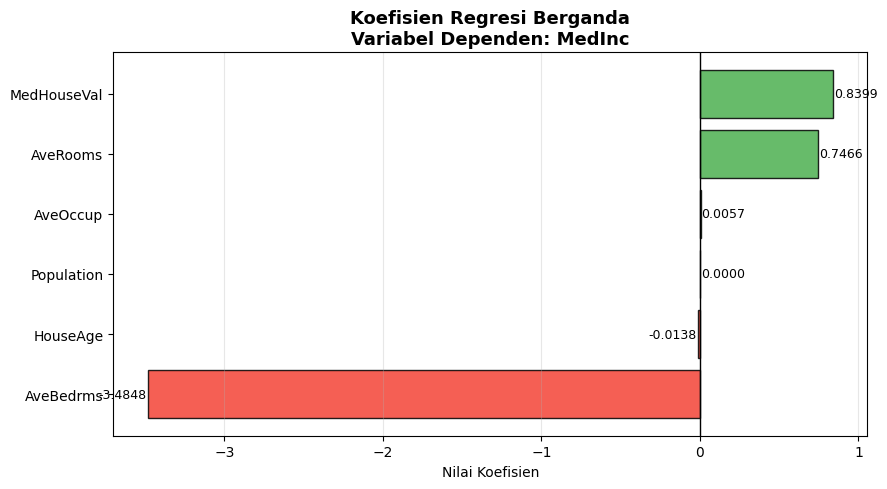


📌 R-squared     : 0.7343
📌 Adj R-squared : 0.7343

📌 Variabel berdasarkan |koefisien| terbesar:
AveBedrms      3.4848
MedHouseVal    0.8399
AveRooms       0.7466
HouseAge       0.0138
AveOccup       0.0057
Population     0.0000
dtype: float64


In [ ]:
coef = model.params.drop('const').sort_values()
colors_bar = ['#F44336' if c < 0 else '#4CAF50' for c in coef]

plt.figure(figsize=(9, 5))
bars = plt.barh(coef.index, coef.values, color=colors_bar, alpha=0.85, edgecolor='black')
plt.axvline(0, color='black', linewidth=1)
plt.title('Koefisien Regresi Berganda\nVariabel Dependen: MedInc', fontsize=13, fontweight='bold')
plt.xlabel('Nilai Koefisien')
for bar, val in zip(bars, coef.values):
    plt.text(val + (0.005 if val >= 0 else -0.005),
             bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center',
             ha='left' if val >= 0 else 'right', fontsize=9)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('soal4_regresi.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📌 R-squared     : {model.rsquared:.4f}')
print(f'📌 Adj R-squared : {model.rsquared_adj:.4f}')
print(f'\n📌 Variabel berdasarkan |koefisien| terbesar:')
print(coef.abs().sort_values(ascending=False).round(4))

### Interpretasi Regresi Berganda

**Variabel Paling Berpengaruh :**
MedHouseVal merupakan variabel paling berpengaruh terhadap MedInc harga rumah dan pendapatan bersifat linear secara sebab akibat. Tanpa pendapatan tinggi, penghuni tidak mungkin mampu membeli properti bernilai tinggi. AveRooms turut berkontribusi sebagai indikator pendukung karena rumah dengan ruangan lebih banyak mencerminkan kemampuan daya beli penghuninya.

**HouseAge :**
HouseAge memiliki pengaruh yang tidak konsisten rumah baru mengindikasikan daerah berkembang dengan pendapatan naik, namun rumah tua di daerah premium juga mencerminkan pendapatan tinggi. Kedua kondisi ini saling cancel out sehingga kontribusinya terhadap model relatif lemah.

**Population :**
Population tidak terlalu berpengaruh langsung terhadap MedInc kontribusinya bersifat kondisional dan sangat bergantung pada produktivitas ekonomi blok tersebut.

**Multicollinearity :**
AveRooms dan AveBedrms berpotensi multicollinearity karena keduanya berada dalam satu konteks yang sama memasukkan keduanya secara bersamaan dapat mendistorsi kontribusi masing-masing variabel dalam model.

**Nilai R-squared :**
Nilai R-squared yang tidak terlalu tinggi bukan berarti ada faktor penting yang terlewat variabel eksternal seperti infrastruktur dan tingkat kriminalitas sudah tercermin secara implisit dalam MedInc itu sendiri, karena pendapatan tinggi otomatis berkorelasi dengan lingkungan yang lebih baik. Keterbatasan model lebih disebabkan oleh potensi multicollinearity antar variabel.

---
## SOAL 5: Analisis Time Series

### 5a. Apakah Time Series Dapat Diterapkan?

California Housing Dataset tidak dapat dianalisis menggunakan Time Series karena tidak memiliki kolom waktu. Dataset ini bersifat cross-sectional dikumpulkan pada satu titik waktu yaitu sensus 1990, sehingga tidak ada urutan temporal yang bisa dianalisis. Namun apabila Trevor mengumpulkan data harga rumah secara berkala misalnya bulanan selama 10 tahun barulah Time Series dapat diterapkan untuk mengidentifikasi tren kenaikan harga dan pola musiman penjualan.

### 5b. Konsep Penting dalam Time Series

**Tren :**
Tren adalah pola jangka panjang yang naik atau turun secara konsisten dalam data. Contoh: harga rumah California yang cenderung naik setiap dekade seiring pertumbuhan ekonomi dan keterbatasan lahan.

**Musiman (Seasonality) :**
Musiman adalah pola yang berulang dalam periode tetap. Contoh: penjualan rumah yang selalu meningkat setiap musim semi dan menurun di musim dingin pola ini berulang setiap tahun secara konsisten.

**Noise :**
Noise adalah fluktuasi acak yang tidak dapat diprediksi dan tidak berulang. Contoh: anjloknya harga rumah akibat krisis finansial 2008 yang terjadi tiba-tiba dan tidak bisa diantisipasi sebelumnya.